# **Лабораторная работа №1: Первичное исследование данных и оценка качества данных(продолжение)**

## **1. Типы признаков и шкалы измерения**

In [ ]:
#номинальная - данные по отдельным категориям и меткам
#порядковая - данные по категориям, упорядочены по признаку, который не может быть количественно измерен
#интервальная - равные интервалы между значениями, условная точка отсчета
#отношений -  равные интервалы между значениями, естественная нулевая точка отсчета

| **Признак** | **Описание** | **Тип шкалы** |
| --- | --- | --- |
| participant_id | Уникальный идентификатор участника | Номинальная |  
| date | Дата изменения | Интервальная  |  
| age | Возраст участника | Шкала отношений |  
| gender | Пол участника | Номинальная |  
| height_cm | Рост | Шкала отношений |  
| weight_kg | Вес | Шкала отношений |  
| bmi | Индекс массы тела | Шкала отношений |  
| activity_type | Тип физической активности | Номинальная |  
| duration_minutes |  Продолжительность активности | Шкала отношений |  
| intensity | Интенсивность активности | Порядковая |  
| calories_burned | Сожжённые калории | Шкала отношений |  
| daily_steps |  Количество пройденных шагов | Шкала отношений |  
| avg_heart_rate | Показатели средней частоты сердцебиения | Шкала отношений |  
| resting_heart_rate | Показатели частоты сердцебиения в покое | Шкала отношений |  
| blood_pressure_systolic | Систолическое артериальное давление | Шкала отношений |  
| blood_pressure_diastolic | Диастолическое артериальное давление | Шкала отношений |  
| endurance_level | Уровень выносливости | Шкала отношений |  
| sleep_hours | Количество сна | Шкала отношений |  
| stress_level | Уровень стресса | Порядковая |  
| hydration_level | Уровень гидратации | Шкала отношений |  
| smoking_status | Статус курящего | Номинальная |  
| health_condition | Состояние здоровья | Номинальная |  
| fitness_level |Уровень физической подготовки | Шкала отношений |  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/data/health_fitness_dataset.csv')  # Путь к вашему файлу

print("Анализ признаков с разными шкалами")

print("\nПризнак 1: age (шкала отношений)")
print("Среднее арифметическое:", df['age'].mean())
print("Медиана:", df['age'].median())
print("Мода:", df['age'].mode()[0])
print("\nВывод по признаку age:")
print("Среднее - математически корректно и методологически верно")
print("Медиана - математически корректно и методологически верно")
print("Мода - математически корректно, но малоинформативна для непрерывных величин")

print("\nПризнак 2: stress_level (порядковая шкала)")
print("Среднее арифметическое:", df['stress_level'].mean())
print("Медиана:", df['stress_level'].median())
print("Мода:", df['stress_level'].mode()[0])

print("\nВывод по признаку stress_level:")
print("Среднее - математически корректно, НО методологически неверно!")
print("(Нельзя усреднять порядковые значения - расстояние между рангами может быть разное: разница между 1 и 2 не равна разнице между 2 и 3)")
print("Медиана - математически корректно и методологически верно")
print("Мода - математически корректно и методологически верно")

Анализ признаков с разными шкалами

Признак 1: age (шкала отношений)
Среднее арифметическое: 41.65860163065053
Медиана: 42.0
Мода: 24

Вывод по признаку age:
Среднее - математически корректно и методологически верно
Медиана - математически корректно и методологически верно
Мода - математически корректно, но малоинформативна для непрерывных величин

Признак 2: stress_level (порядковая шкала)
Среднее арифметическое: 5.472029268533854
Медиана: 5.0
Мода: 5

Вывод по признаку stress_level:
Среднее - математически корректно, НО методологически неверно!
(Нельзя усреднять порядковые значения - расстояние между рангами может быть разное: разница между 1 и 2 не равна разнице между 2 и 3)
Медиана - математически корректно и методологически верно
Мода - математически корректно и методологически верно


## **2. Пропуски и их природа (MCAR / MAR / MNAR)**

Признак `health_condition`.  

*Гипотезы о пропусках:*
* MCAR — пропуски случайны (например, случайный сбой ввода)
* MAR — пропуски зависят от других наблюдаемых признаков (например, люди старше 60 лет реже заполняют поле)
* MNAR — пропуски зависят от самого пропущенного значения (например, люди с тяжёлыми болезнями скрывают это; люди не указали значение в поле, потому что здоровы )

*Проверки:*  
* MCAR: сравним распределение других признаков для строк с пропусками и без. Если различий нет — MCAR.
* MAR: проверим корреляцию пропусков с другими признаками (логистическая регрессия на индикаторе пропуска).
* MNAR: сложно проверить без внешних данных, но можно провести опрос.

Количество пропусков в столбце health_condition:
490275

Проверка гипотезы MCAR:


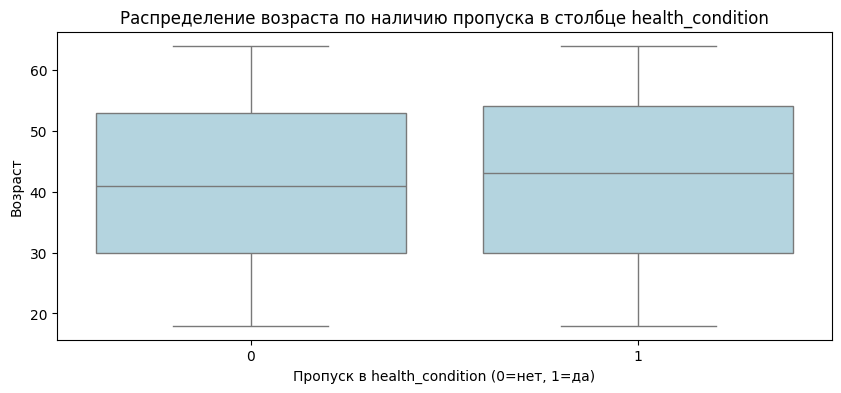

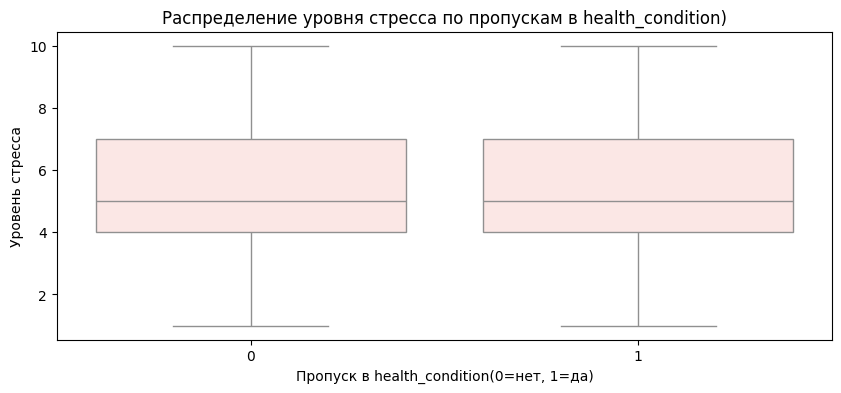

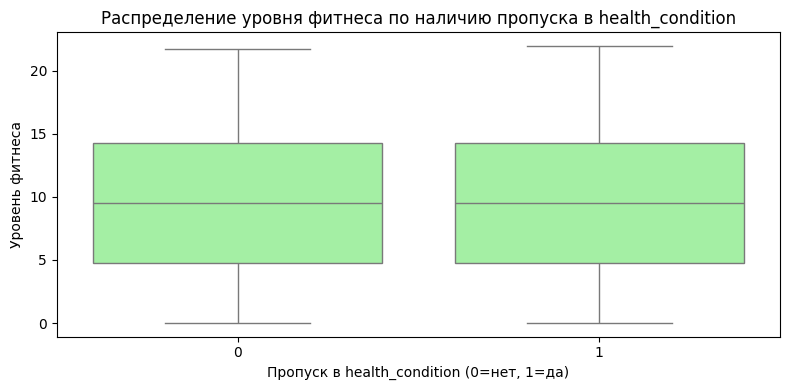

In [ ]:
print("Количество пропусков в столбце health_condition:")
print(df["health_condition"].isnull().sum())

# Создаём индикатор пропуска
df["health_condition_missing"] = df["health_condition"].isnull().astype(int)


print("\nПроверка гипотезы MCAR:")
# Проверяем различия в возрасте для пропущенных и заполненных
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["health_condition_missing"], y=df["age"],color='lightblue')
plt.title("Распределение возраста по наличию пропуска в столбце health_condition")
plt.xlabel('Пропуск в health_condition (0=нет, 1=да)')
plt.ylabel('Возраст')

# Проверяем различия в уровне стресса для пропущенных и заполненных
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[f'health_condition_missing'], y=df['stress_level'],color='mistyrose')
plt.title(f"Распределение уровня стресса по пропускам в health_condition)")
plt.xlabel("Пропуск в health_condition(0=нет, 1=да)")
plt.ylabel("Уровень стресса")

# Проверяем различия в уровне фитнеса для пропущенных и заполненных
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['health_condition_missing'], y=df['fitness_level'],color='palegreen')
plt.title('Распределение уровня фитнеса по наличию пропуска в health_condition')
plt.xlabel('Пропуск в health_condition (0=нет, 1=да)')
plt.ylabel('Уровень фитнеса')
plt.tight_layout()
plt.show()

**Анализ boxplot-ов:**
* На первом графике видно, что распределения возраста для строк с пропусками (health_condition_missing = 1) и без пропусков (health_condition_missing = 0) различаются. Медианы не совпадают, что указывает на систематические различия. Это опровергает гипотезу MCAR — пропуски не являются полностью случайными, они коррелируют с возрастом.
* Остальные распределения - по уровню стресса и по уровню фитнеса, имеют графики для строк с пропусками и без - очень похожие. Это говорит о том, что уровень стресса и фитнеса не влияет на появление пропусков в health_condition.  

**Вывод по MCAR:** гипотеза отвергается, так как хотя бы для одного признака (возраста) распределение отличается между группами с пропусками и без.

In [ ]:
# Логистическая регрессия для проверки MAR
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
print("Проверка гипотезы MAR:")

features = ['age', 'bmi', 'fitness_level', 'stress_level', 'sleep_hours', 'daily_steps']
# Кодируем пол
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'].fillna('Unknown'))

X = df[features + ['gender_encoded']].dropna()
y = df.loc[X.index, 'health_condition_missing']

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Обучаем логистическую регрессию
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

# Выводим важность признаков
feature_importance = pd.DataFrame({
    'Признак': features + ['gender'],
    'Коэффициент': model.coef_[0]
})
feature_importance['Абс. коэффициент'] = np.abs(feature_importance['Коэффициент'])
feature_importance = feature_importance.sort_values('Абс. коэффициент', ascending=False)

print("\nВажность признаков для предсказания пропусков:")
print(feature_importance.to_string(index=False))

**Анализ коэффициентов логистической регрессии:**
* `Возраст (age)`: коэффициент 0.060424 — самый высокий по модулю. Положительный знак означает, что с ростом возраста вероятность пропуска в health_condition увеличивается.  
* `BMI (bmi)`: коэффициент 0.052613 — второй по значимости. Это говорит о связи между индексом массы тела и пропусками.  
* `Пол (gender)`: коэффициент -0.045686. Отрицательный знак может означать, что один из полов (в зависимости от кодирования) реже имеет пропуски.
* `Остальные признаки (fitness_level, sleep_hours, stress_level, daily_steps)` имеют очень низкие коэффициенты (около 0.002 – 0.003), что говорит о слабой связи с пропусками.  

**Вывод по MAR:** гипотеза подтверждается, так как пропуски коррелируют с наблюдаемыми признаками (в первую очередь с возрастом и BMI). Это означает, что механизмы пропусков можно частично объяснить данными, которые уже есть в наборе.  

**Проверка гипотезы MNAR:** Такую гипотезу трудно проверить статистически — нужны дополнительные данные или контекст.
*Предложенные шаги:*
* Провести опрос респондентов, у которых есть пропуски, чтобы выяснить причины (например, нежелание раскрывать информацию о здоровье).  
* Сравнить данные с другими исследованиями в той же области — есть ли схожие паттерны пропусков.  
* Проанализировать, не связаны ли пропуски с чувствительностью темы (здоровье, хронические заболевания).  

**Вывод по MNAR:** гипотезу нельзя ни подтвердить, ни опровергнуть на основе текущих данных. Требуется сбор дополнительной информации.

## **3. Индикатор пропуска как источник информации**

### 1. Объясните, в каком случае сам факт пропуска несёт информацию?  
Факт пропуска несёт информацию, когда он не случаен (MAR или MNAR) и связан с целевой переменной или важными характеристиками (например, в фитнес-трекерах: пропуск пульса = устройство снято).

### 2. Почему значимость индикатора в модели - это сигнал о неправильной или грубой импутации?  
Если индикатор пропуска значим в модели, значит:
1) Мы не смогли восстановить реальное значение при импутации
2) Группы с пропусками и без принципиально разные
3) Простая импутация (средним/медианой) исказила распределение  

Плохая импутация - замена средним по всем. Хорошая импутация - предсказание на основе других признаков.

### 3. Примеры признака для индикатора пропуска
1) полезен (индикатор несёт информацию):
* Признак: health_condition"  
* Почему: пропуск может означать 'отсутствие хронических заболеваний'
* Решение: создать категорию 'Нет заболеваний' вместо NaN"  

2) бесполезен (индикатор не несёт информации):
* Признак: participant_id"
* Почему: если ID пропущен - вся строка должна быть удалена
* Решение: удалить строку, индикатор не нужен

3) опасен (индикатор может исказить анализ):
* Признак: daily_steps с отрицательными значениями
* Почему: если создать индикатор 'была ошибка' и просто убрать NaN, модель может выучить, что отрицательные шаги - это нормально
* Решение: исправить ошибку, а не маркировать её


## **4. Выброс - это ошибка или сигнал?**


Анализируемый признак: avg_heart_rate (средний пульс)


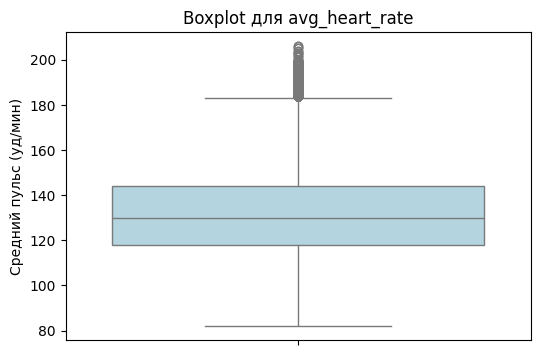


Статистика:
Нижняя граница значений: 79.0
Верхняя граница значений: 183.0
Количество выбросов: 1867 (0.27%)
Минимальное значение в выбросах: 184 уд/мин
Максимальное значение в выбросах: 206 уд/мин
Анализ конкретного выброса

Данные участника с выбросом:
Пульс: 206 уд/мин
Возраст: 18 лет
Тип активности: Dancing
Интенсивность: High
Длительность: 105.2 мин
Пульс в покое: 80.6 уд/мин

1) Какие реальные причины могут объяснить это значение?

1. Физиологические:
Молодой возраст; высокая нагрузка в виде танцев с максимальной интенсивностью
Индивидуальные особенности организма (max HR = 220 - возраст)
2️. Технические:
Сбой датчика пульса (плохой контакт с кожей)
3️. Медицинские:
Тахикардия; обезвоживание; стресс/паническая атака 

2) Что хуже для анализа?

Оригинальные данные:
Среднее арифм: 131.5
Стандартное отклонение: 17.8

Данные после удаления выбросов:
Среднее арифм: 131.3
Стандартное отклонение: 17.6
Изменение на:0.1534

Данные без изменений:
Среднее арифм: 131.5
Стандартное отклонение

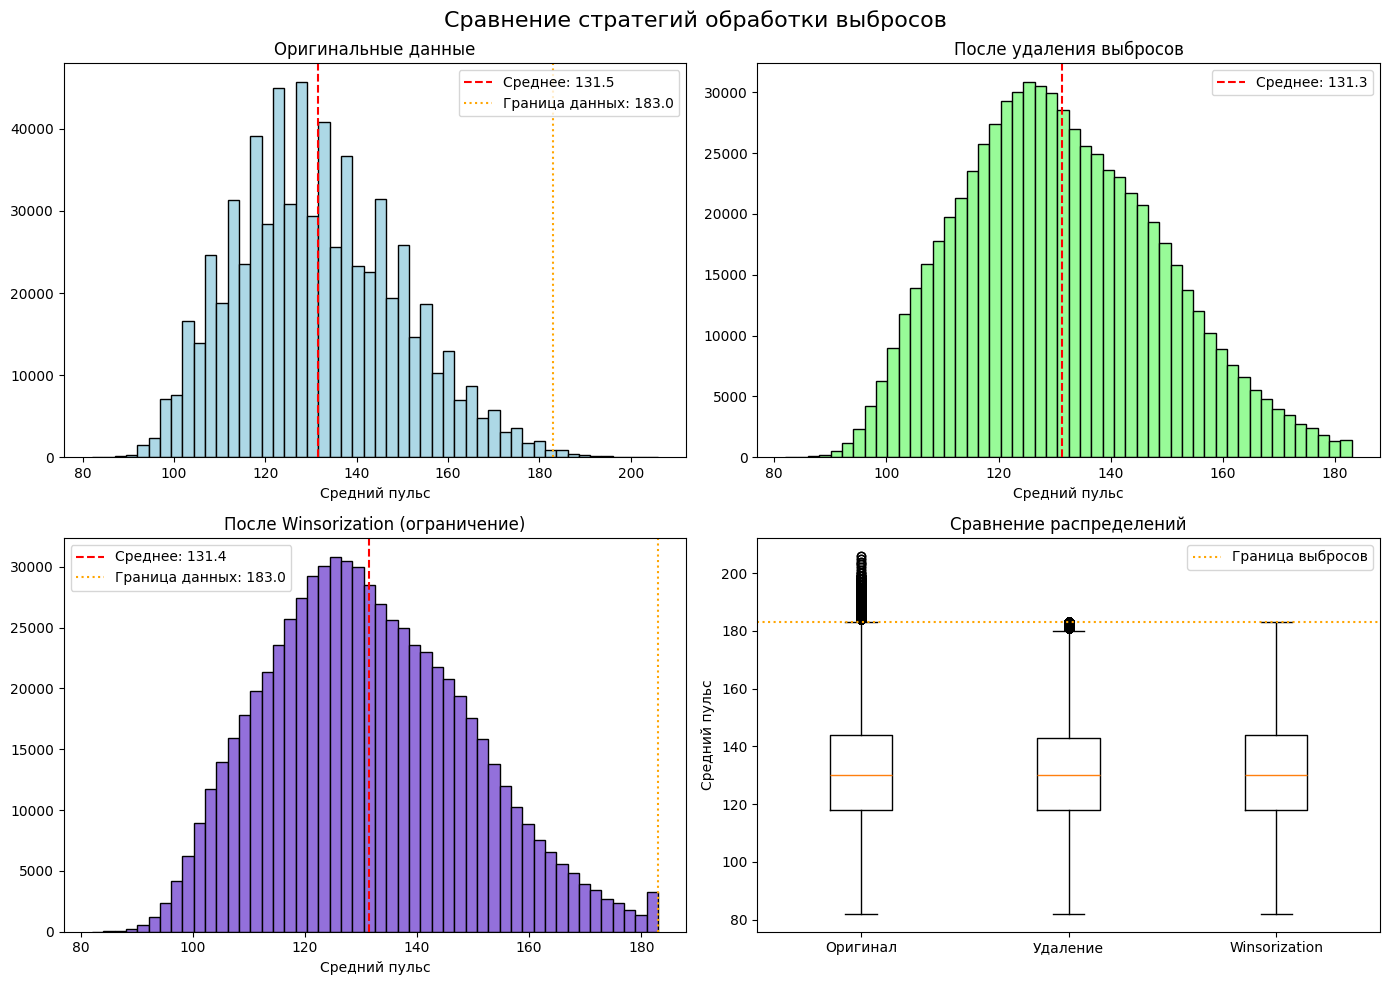

In [ ]:
print("\nАнализируемый признак: avg_heart_rate (средний пульс)")
# Находим выбросы методом IQR
Q1 = df['avg_heart_rate'].quantile(0.25)
Q3 = df['avg_heart_rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['avg_heart_rate'] < lower_bound) | (df['avg_heart_rate'] > upper_bound)]
# Визуализация
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, y='avg_heart_rate',color='lightblue')
plt.title(f'Boxplot для {'avg_heart_rate'}')
plt.ylabel('Средний пульс (уд/мин)')
plt.show()

print(f"\nСтатистика:")
print(f"Нижняя граница значений: {lower_bound:.1f}")
print(f"Верхняя граница значений: {upper_bound:.1f}")
print(f"Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Минимальное значение в выбросах: {outliers['avg_heart_rate'].min()} уд/мин")
print(f"Максимальное значение в выбросах: {outliers['avg_heart_rate'].max()} уд/мин")

# Анализируем конкретный выброс
sample_outlier = outliers[outliers['avg_heart_rate'] == outliers['avg_heart_rate'].max()].iloc[0]
print("Анализ конкретного выброса")
print(f"\nДанные участника с выбросом:")
print(f"Пульс: {sample_outlier['avg_heart_rate']} уд/мин")
print(f"Возраст: {sample_outlier['age']} лет")
print(f"Тип активности: {sample_outlier['activity_type']}")
print(f"Интенсивность: {sample_outlier['intensity']}")
print(f"Длительность: {sample_outlier['duration_minutes']} мин")
print(f"Пульс в покое: {sample_outlier['resting_heart_rate']} уд/мин")

print("\n1) Какие реальные причины могут объяснить это значение?")
print("""
1. Физиологические:
Молодой возраст; высокая нагрузка в виде танцев с максимальной интенсивностью
Индивидуальные особенности организма (max HR = 220 - возраст)
2️. Технические:
Сбой датчика пульса (плохой контакт с кожей)
3️. Медицинские:
Тахикардия; обезвоживание; стресс/паническая атака """)


print("\n2) Что хуже для анализа?")
# Оригинальные данные
original_mean = df['avg_heart_rate'].mean()
original_std = df['avg_heart_rate'].std()
print(f"\nОригинальные данные:")
print(f"Среднее арифм: {original_mean:.1f}")
print(f"Стандартное отклонение: {original_std:.1f}")

# 1. Удаление выбросов
df_no_outliers = df[(df['avg_heart_rate'] >= lower_bound) & (df['avg_heart_rate'] <= upper_bound)]
remove_mean = df_no_outliers['avg_heart_rate'].mean()
remove_std = df_no_outliers['avg_heart_rate'].std()
print(f"\nДанные после удаления выбросов:")
print(f"Среднее арифм: {remove_mean:.1f}")
print(f"Стандартное отклонение: {remove_std:.1f}")
print(f"Изменение на:{original_mean-remove_mean:.4f}")

# 2. Оставить без изменений
keep_mean = original_mean
keep_std = original_std
print(f"\nДанные без изменений:")
print(f"Среднее арифм: {keep_mean:.1f}")
print(f"Стандартное отклонение: {keep_std:.1f}")
print(f"Изменение на:{original_mean-keep_mean:.1f}")

# 3. Применить преобразование (winsorization)
df_winsorized = df.copy()
df_winsorized['avg_heart_rate'] = df_winsorized['avg_heart_rate'].clip(upper=upper_bound)
winsor_mean = df_winsorized['avg_heart_rate'].mean()
winsor_std = df_winsorized['avg_heart_rate'].std()
print(f"\nДанные после преобразований:")
print(f"Среднее арифм: {winsor_mean:.1f}")
print(f"Стандартное отклонение: {winsor_std:.1f}")
print(f"Изменение на:{original_mean-winsor_mean:.4f}")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение стратегий обработки выбросов', fontsize=16)

# Оригинал
axes[0, 0].hist(df['avg_heart_rate'], bins=50, color='lightblue', edgecolor='black')
axes[0, 0].axvline(original_mean, color='red', linestyle='--', label=f'Среднее: {original_mean:.1f}')
axes[0, 0].axvline(upper_bound, color='orange', linestyle=':', label=f'Граница данных: {upper_bound:.1f}')
axes[0, 0].set_title('Оригинальные данные')
axes[0, 0].set_xlabel('Средний пульс')
axes[0, 0].legend()

# После удаления
axes[0, 1].hist(df_no_outliers['avg_heart_rate'], bins=50, color='palegreen', edgecolor='black')
axes[0, 1].axvline(remove_mean, color='red', linestyle='--', label=f'Среднее: {remove_mean:.1f}')
axes[0, 1].set_title('После удаления выбросов')
axes[0, 1].set_xlabel('Средний пульс')
axes[0, 1].legend()

# После winsorization
axes[1, 0].hist(df_winsorized['avg_heart_rate'], bins=50, color='mediumpurple', edgecolor='black')
axes[1, 0].axvline(winsor_mean, color='red', linestyle='--', label=f'Среднее: {winsor_mean:.1f}')
axes[1, 0].axvline(upper_bound, color='orange', linestyle=':', label=f'Граница данных: {upper_bound:.1f}')
axes[1, 0].set_title('После Winsorization (ограничение)')
axes[1, 0].set_xlabel('Средний пульс')
axes[1, 0].legend()

# Boxplot сравнение
axes[1, 1].boxplot([df['avg_heart_rate'].dropna(),
                    df_no_outliers['avg_heart_rate'].dropna(),
                    df_winsorized['avg_heart_rate'].dropna()],
                   tick_labels=['Оригинал', 'Удаление', 'Winsorization'])
axes[1, 1].set_title('Сравнение распределений')
axes[1, 1].set_ylabel('Средний пульс')
axes[1, 1].axhline(upper_bound, color='orange', linestyle=':', label='Граница выбросов')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

**Сравнение стратегий:**  
1)Оставить данные без изменений.  
*Плюсы:* сохраняется полная картина данных, включая крайние значения, что может быть важно для некоторых видов анализа (для изучения экстремальных значений).  
*Минусы:* выбросы искажают распределение, увеличивают разброс данных (стандартное отклонение), могут негативно влиять на модели машинного обучения, делая их менее устойчивыми к аномалиям.

2)Удалить выбросы.  
*Плюсы:* распределение становится более «чистым», уменьшается влияние экстремальных значений;  
модели машинного обучения становятся более устойчивыми;  
стандартное отклонение уменьшается, что говорит о меньшей вариабельности данных.  
*Минусы:* потеря части данных (1867 наблюдений), что может быть критично для небольших выборок;  
если выбросы отражают важные закономерности (например, реакции на экстремальные нагрузки), их удаление приведёт к потере информации.

3)Применить преобразование.  
*Плюсы:* сохраняется объём данных;  
уменьшается влияние выбросов на статистику (среднее значение ближе к данным без выбросов);  
метод менее агрессивен по сравнению с удалением, так как не теряет наблюдения.  
*Минусы:*
распределение остаётся немного искажённым (стандартное отклонение практически не изменилось);  
преобразованные значения являются искусственными, что может быть критично для некоторых видов анализа.  

**Выводы по стратегиям:**
* *Хуже всего* оставлять выбросы без изменений, если они вызваны ошибками измерения или не несут смысловой нагрузки для анализа — это искажает статистику (увеличивает разброс) и может привести к некорректным выводам.  
* Удаление выбросов — наиболее радикальный метод, который лучше всего подходит при явных ошибках измерения, но сопряжён с потерей данных.  
* Winsorization — *оптимальный компромисс*: сохраняет объём данных и уменьшает влияние выбросов, не искажая при этом общую картину. Подходит, если выбросы не несут смысловой нагрузки для анализа и вызваны ошибками измерений.

## **5. Преобразование или винзоризация?**

In [ ]:
from scipy.stats import skew, boxcox
import warnings
warnings.filterwarnings('ignore')

# Выбираем только числовые признаки
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Создаём таблицу асимметрии
skewness_data = []
for col in numeric_cols:
    skew_val = df[col].skew()
    skewness_data.append({
        'Признак': col,
        'Асимметрия': skew_val,
        'Степень асимметрии': 'Сильная (>1)' if abs(skew_val) > 1 else
                              ('Умеренная (0.5-1)' if abs(skew_val) > 0.5 else 'Слабая (<0.5)')
    })

skew_df = pd.DataFrame(skewness_data)
skew_df = skew_df.sort_values('Асимметрия', ascending=False)
print(skew_df.to_string(index=False))

# Выбираем признак с наибольшей асимметрией
most_skewed = skew_df.iloc[0]['Признак']
print(f"\nВыбираем признак с наибольшей асимметрией: {most_skewed}")
print(f"Значение асимметрии: {skew_df.iloc[0]['Асимметрия']:.3f}")

                 Признак  Асимметрия Степень асимметрии
         calories_burned    1.235929       Сильная (>1)
               weight_kg    0.381568      Слабая (<0.5)
          avg_heart_rate    0.360952      Слабая (<0.5)
          gender_encoded    0.294742      Слабая (<0.5)
        duration_minutes    0.216051      Слабая (<0.5)
         endurance_level    0.191474      Слабая (<0.5)
               height_cm    0.179715      Слабая (<0.5)
blood_pressure_diastolic    0.132936      Слабая (<0.5)
             daily_steps    0.062185      Слабая (<0.5)
            stress_level    0.048490      Слабая (<0.5)
                     bmi    0.026378      Слабая (<0.5)
           fitness_level    0.023257      Слабая (<0.5)
      resting_heart_rate    0.008333      Слабая (<0.5)
             sleep_hours    0.007850      Слабая (<0.5)
         hydration_level    0.001448      Слабая (<0.5)
          participant_id    0.000852      Слабая (<0.5)
                     age   -0.063646      Слабая

Применяем разные преобразования для признака calories_burned

Статистика после преобразований:
Метод          Асимметрия   Среднее      Медиана      Станд.откл. 
-----------------------------------------------------------------
Исходные       1.236        15.381       13.000       9.986       
Логарифм       -0.189       2.613        2.639        0.620       
Корень         0.447        3.726        3.606        1.225       
Винзоризация   0.718        15.054       13.000       8.879       


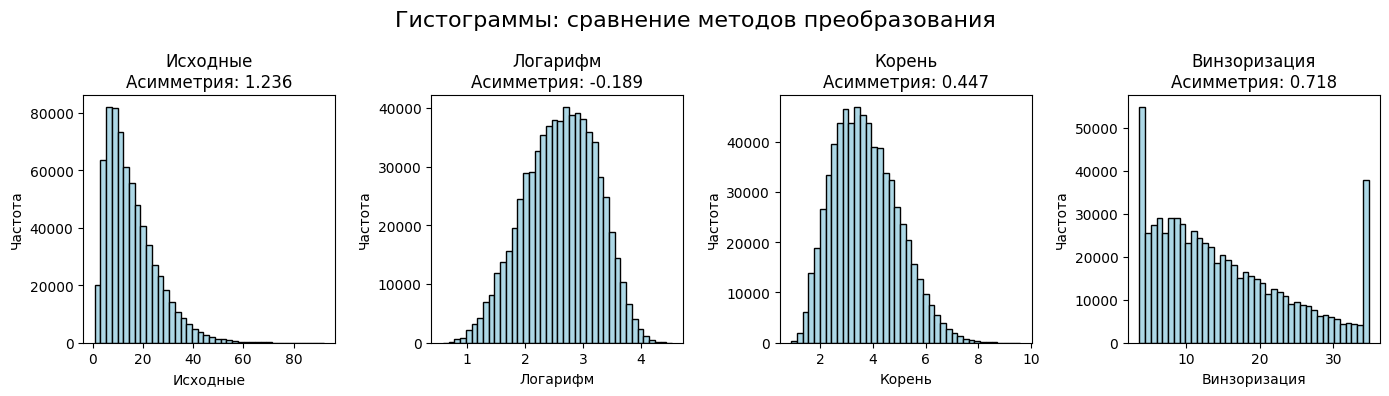

In [ ]:
print("Применяем разные преобразования для признака calories_burned")

# Берём наш признак и убираем пропуски
data = df[most_skewed].dropna()

# 1. Логарифмирование (log)
data_log = np.log1p(data)  # log(1+x) чтобы избежать log(0)
# 2. Квадратный корень (sqrt)
data_sqrt = np.sqrt(data)
# 3. Винзоризация (отсекаем крайние 5% с каждой стороны)
lower_percentile = np.percentile(data, 5)
upper_percentile = np.percentile(data, 95)
data_winsor = data.clip(lower_percentile, upper_percentile)

# Собираем данные в один DataFrame
transformed_data = {
    'Исходные': data,
    'Логарифм': data_log,
    'Корень': data_sqrt,
    'Винзоризация': data_winsor
}

# Выводим статистику по каждому преобразованию
print("\nСтатистика после преобразований:")
print(f"{'Метод':<14} {'Асимметрия':<12} {'Среднее':<12} {'Медиана':<12} {'Станд.откл.':<12}")
print("-" * 65)

for name, values in transformed_data.items():
    skewness = values.skew()
    mean_val = values.mean()
    median_val = values.median()
    std_val = values.std()
    print(f"{name:<14} {skewness:<12.3f} {mean_val:<12.3f} {median_val:<12.3f} {std_val:<12.3f}")

# Гистограммы для всех преобразований
fig, axes = plt.subplots(1, 4, figsize=(14,4))
fig.suptitle('Гистограммы: сравнение методов преобразования', fontsize=16)

for idx, (name, values) in enumerate(transformed_data.items()):
    axes[idx].hist(values.dropna(), bins=40, color='lightblue', edgecolor='black')
    axes[idx].set_title(f'{name}\nАсимметрия: {values.skew():.3f}')
    axes[idx].set_xlabel(name)
    axes[idx].set_ylabel('Частота')

plt.tight_layout()
plt.show()


### 1. В каких случаях предпочтительнее каждый метод преобразования?  
1. *Логарифмирование*  
* данные имеют экспоненциальный рост;
* нужно сжать диапазон значений;
* распределение имеет длинный правый хвост;
* планируется использование линейных моделей — логарифмирование помогает приблизить распределение к нормальному.  
Подходит для задач, где важна относительная шкала.

2. *Корень*  
* асимметрия не слишком сильная;
* нужно сохранить больше информации о малых значениях;
* данные имеют физический смысл, где квадратичная зависимость правдоподобна;
* требуется баланс между сжатием и сохранением детализации.  
Хорошо работает, когда данные не имеют экстремальных выбросов, но всё ещё асимметричны.

3. *Винзоризация*  
* важно сохранить исходную шкалу измерений;
* данные содержат выбросы, которые не хочется удалять, но нужно «приглушить» их влияние;
* анализ предполагает сохранение большинства исходных значений (только крайние значения заменяются на процентили);
* используется в машинном обучении для стабилизации моделей.  
Подходит для задач, где интерпретируемость данных критична, но распределение всё ещё далеко от нормального.  

### 2. Как эти подходы влияют на анализ?
1. `Интерпретируемость`  
- Логарифм: ухудшает интерпретируемость — значения становятся «логарифмическими калориями», а не реальными.  
- Корень: сохраняет частичную интерпретируемость — значения можно возвести в квадрат, чтобы вернуться к исходным калориям.  
- Винзоризация: лучшая интерпретируемость — значения остаются в исходной шкале, только крайние значения «обрезаны».

2. `Линейные модели`  
- Логарифм: лучше всего подходит для линейных моделей — минимизирует асимметрию (до –0.189), улучшает линейность связей, снижает влияние выбросов.  
- Корень: умеренно улучшает линейность, но асимметрия остаётся заметной (0.447).  
- Винзоризация: уменьшает влияние выбросов, но не устраняет асимметрию полностью (0.718). Подходит для стабилизации обучения, но не всегда улучшает линейность.  

3. `Визуализацию распределений`  
*Исходные данные:* сильный правый хвост, высокая асимметрия (1.236) — сложно оценить центральную тенденцию.  
- Логарифм: распределение становится почти симметричным (асимметрия –0.189), «хвост» практически исчезает. Отлично для визуализации нормальности, но шкала неочевидна.  
- Корень: асимметрия снижается (0.447), распределение становится более «куполообразным», но всё ещё с небольшим хвостом. Хорошо балансирует между исходным масштабом и симметрией.  
- Винзоризация: «обрезает» крайние значения, но форма хвоста сохраняется (асимметрия 0.718). Гистограмма выглядит «усечённой» — видно, где были выбросы.

## **6. Средние, которые вводят в заблуждение**

Анализируем признак: weight_kg (вес в кг)

Расчёт всредних:
Арифметическое среднее: 61.7282 кг
Медиана: 61.0600 кг
Геометрическое среднее: 61.1446 кг

Статистика распределения:
Мин значение: 39.76 кг
Макс значение: 98.11 кг
СКО: 8.55 кг
Асимметрия: 0.382


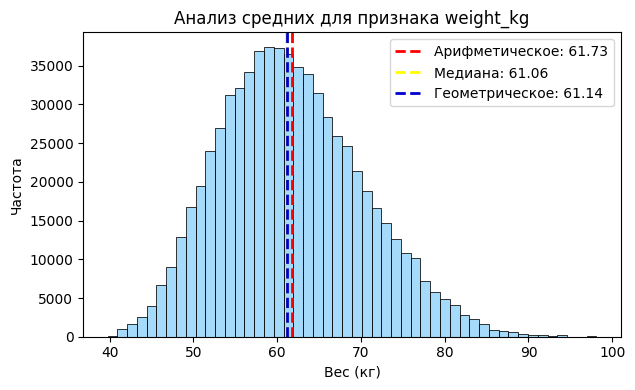

In [ ]:
from scipy import stats

print(f"Анализируем признак: weight_kg (вес в кг)")
data = df['weight_kg'].dropna()

print("\nРасчёт всредних:")
arith_mean = data.mean()
print(f"Арифметическое среднее: {arith_mean:.4f} кг")

median = data.median()
print(f"Медиана: {median:.4f} кг")

geo_mean = stats.gmean(data)
print(f"Геометрическое среднее: {geo_mean:.4f} кг")

print("\nСтатистика распределения:")
print(f"Мин значение: {data.min():.2f} кг")
print(f"Макс значение: {data.max():.2f} кг")
print(f"СКО: {data.std():.2f} кг")
print(f"Асимметрия: {data.skew():.3f}")

# Визуализация
plt.figure(figsize=(12, 4))
#KDE
plt.subplot(1, 2, 1)
sns.histplot(data, bins=50, color='lightskyblue', edgecolor='black')
plt.axvline(arith_mean, color='red', linewidth=2, linestyle='--',
                label=f'Арифметическое: {arith_mean:.2f}')
plt.axvline(median, color='yellow', linewidth=2, linestyle='--',
                label=f'Медиана: {median:.2f}')
plt.axvline(geo_mean, color='mediumblue', linewidth=2, linestyle='--',
                label=f'Геометрическое: {geo_mean:.2f}')
plt.title(f'Анализ средних для признака weight_kg')
plt.xlabel('Вес (кг)')
plt.ylabel('Частота')
plt.legend()

plt.tight_layout()
plt.show()

### 1. Сравните арифметическое, медиану и геометрическое среднее.  
На графике видно, что все три показателя находятся в близком диапазоне - около 61 кг, что говорит об относительно симметричном распределении данных с небольшой асимметрией = 0,382.  

### 2.1. Почему значения различаются?  
*Арифметическое среднее* наиболее чувствительно к экстремальным значениям (выбросам). Максимальное значение — 98,11 кг, минимальное — 39,76 кг, влияют на арифметическое среднее.  
*Медиана* абсолютно не чувствительна к выбросам. Она просто делит данные пополам, поэтому остаётся более «устойчивой» метрикой.  
*Геометрическое среднее* менее чувствительно к экстремальным значениям, чем арифметическое. Оно «сглаживает» влияние очень больших или маленьких значений.  

### 2.2. Какое из них лучше отражает «типичное» значение и почему?  
Наиболее подходящим показателем для отражения «типичного» значения в данном случае является *медиана* (61,06 кг).
* Устойчива к выбросам: медиана не зависит от крайних значений, что особенно важно для реальных данных о весе, где могут встречаться аномальные значения.
* Репрезентативна.
* Небольшая асимметрия распределения: коэффициент асимметрии (0,382) указывает на лёгкое смещение распределения, но не настолько сильное, чтобы кардинально менять выбор метрики. Медиана становится предпочтительнее арифметического среднего.

## **7. Неправильная диаграмма**

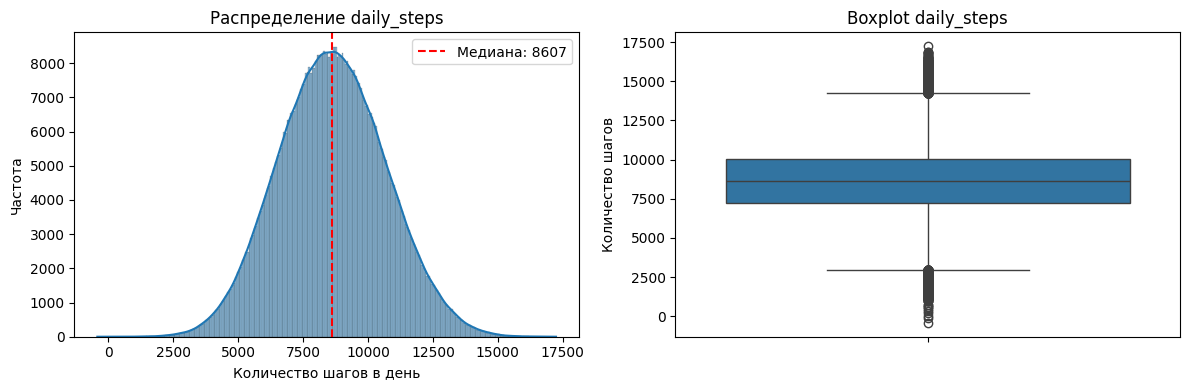

Медиана: 8607.00
Среднее: 8628.37
Стандартное отклонение: 2054.76
Асимметрия: 0.062
Минимум: -419
Максимум: 17241


In [ ]:
#Визуализация из предыдущей работы
# Признак: пройденные шаги
numeric_col = 'daily_steps'

plt.figure(figsize=(12, 4))
#KDE
plt.subplot(1, 2, 1)
sns.histplot(df[numeric_col], kde=True)
plt.axvline(df['daily_steps'].median(), color='red', linestyle='--',
                label=f'Медиана: {df["daily_steps"].median():.0f}')
plt.title(f'Распределение {numeric_col}')
plt.xlabel('Количество шагов в день')
plt.ylabel('Частота')
plt.legend()

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df[numeric_col])
plt.title(f'Boxplot {numeric_col}')
plt.ylabel('Количество шагов')
plt.tight_layout()
plt.show()

print(f"Медиана: {df[numeric_col].median():.2f}")
print(f"Среднее: {df[numeric_col].mean():.2f}")
print(f"Стандартное отклонение: {df[numeric_col].std():.2f}")
print(f"Асимметрия: {df[numeric_col].skew():.3f}")
print(f"Минимум: {df[numeric_col].min():.0f}")
print(f"Максимум: {df[numeric_col].max():.0f}")

Эти диаграммы *хороши* для daily_steps, потому что:
* Гистограмма показывает вид распределения - близко к нормальному
* KDE даёт сглаженную картину плотности
* Boxplot показывает медиану, квартили и выбросы
* Виден диапазон: от ~0 до ~17000 шагов

Диаграмма, которая хуже для daily_steps


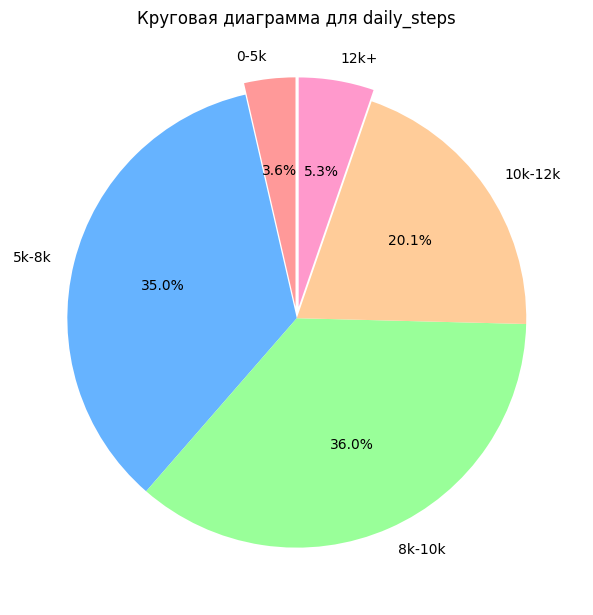

In [ ]:
print("Диаграмма, которая хуже для daily_steps")

#круговая диаграмма
bins = [0, 5000, 8000, 10000, 12000, 18000]
labels = ['0-5k', '5k-8k', '8k-10k', '10k-12k', '12k+']
df['steps_category'] = pd.cut(df['daily_steps'], bins=bins, labels=labels)

# Считаем частоты
category_counts = df['steps_category'].value_counts().sort_index()

# Цвета для круговой диаграммы
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
plt.figure(figsize=(12, 7))
plt.subplot(1, 2, 1)
plt.pie(category_counts.values,
                                labels=category_counts.index,
                                colors=colors,
                                autopct='%1.1f%%',
                                startangle=90,
                                explode=[0.05, 0, 0, 0, 0.05])
plt.title(f'Круговая диаграмма для {numeric_col}')

plt.tight_layout()
plt.show()

### 1. Какую информацию искажает кругова диаграмма?  
*Не видно:*
* вид распределения - только доли в категориях
* выбросов
* медианы
* асимметрию
* точных значений по осям - только проценты и категории.

**Проблемы:**
* Потеря информации о распределении внутри категорий - какой уровень активности
* Произвольная граница категорий. Измени границы - изменятся доли!
* Не видна симметрия распределения

### 2. Какой неверный вывод мог бы сделать зритель?  
1. Иллюзия большинства (распределение почти равномерно вокруг медианы, нет "большинства" - данные распределены непрерывно!)
2. Потеря экстремальных значений  
Зритель не видит, что: есть люди с 13000 шагов (просто активные), а есть люди с 17000 шагов (супер-активные). Они очень разные, но на диаграмме выглядят одинаково!
3. Ложное впечатление о границах
4. Зритель видит только доли категорий и не может определить, что половина людей проходит меньше 8607 шагов (медиана), а половина - больше.

## **8. Одна и та же информация - разные графики**

In [ ]:
print("Анализ признаков: activity_type - тип физической активности; calories_burned - кол-во соженных калорий")

print("\nРаспределение участников по типам активности:")
activity_counts = df['activity_type'].value_counts()
for activity, count in activity_counts.items():
    print(f"{activity}: {count} участников ({count/len(df)*100:.1f}%)")

print("\nСтатистика калорий по типам активности:")
age_by_activity = df.groupby('activity_type')['calories_burned'].agg(['mean', 'median', 'min', 'max', 'count']).round(1)
print(age_by_activity.sort_values('median', ascending=False).to_string())

Анализ признаков: activity_type - тип физической активности; calories_burned - кол-во соженных калорий

Распределение участников по типам активности:
Yoga: 69961 участников (10.2%)
Weight Training: 69661 участников (10.1%)
HIIT: 69376 участников (10.1%)
Dancing: 69193 участников (10.1%)
Cycling: 69187 участников (10.1%)
Basketball: 68536 участников (10.0%)
Tennis: 68533 участников (10.0%)
Walking: 68077 участников (9.9%)
Swimming: 68032 участников (9.9%)
Running: 67145 участников (9.8%)

Статистика калорий по типам активности:
                 mean  median  min   max  count
activity_type                                  
HIIT             26.0    24.3  3.3  92.0  69376
Running          21.3    19.9  2.6  84.0  67145
Cycling          18.5    17.3  2.2  72.5  69187
Basketball       17.4    16.1  2.2  60.1  68536
Tennis           15.8    14.8  2.0  53.9  68533
Swimming         15.2    14.1  1.8  53.2  68032
Weight Training  13.0    12.1  1.5  50.4  69661
Dancing          12.0    11.2  1.5 

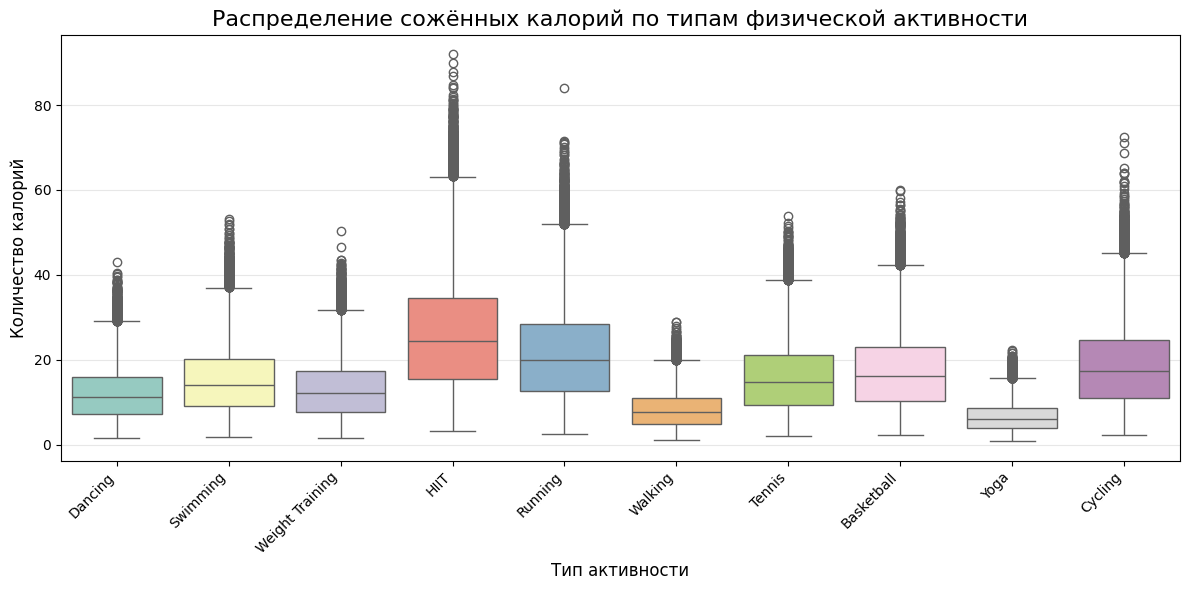

In [19]:
# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='activity_type', y='calories_burned', data=df, palette='Set3')
plt.title('Распределение сожённых калорий по типам физической активности', fontsize=16)
plt.xlabel('Тип активности', fontsize=12)
plt.ylabel('Количество калорий', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Какую информацию подчёркивает Boxplot?
* Медиана и квартили для отчётов.
* Разброс данных (диапазон «усов»): показывает, насколько вариативно количество сожжённых калорий внутри одного типа активности.
* Выбросы - аномальные значения, для дальнейшего анализа.
* Быстрое сравнение активностей: видно, что HIIT и Running сжигают больше калорий, чем йога или ходьба (Walking).  
### Какие гипотезы можно заметить?
* есть ли значительные различия в медианах между типами активности;
* насколько данные смещены;
* присутствуют ли выбросы, которые могут указывать на аномальные тренировки.  

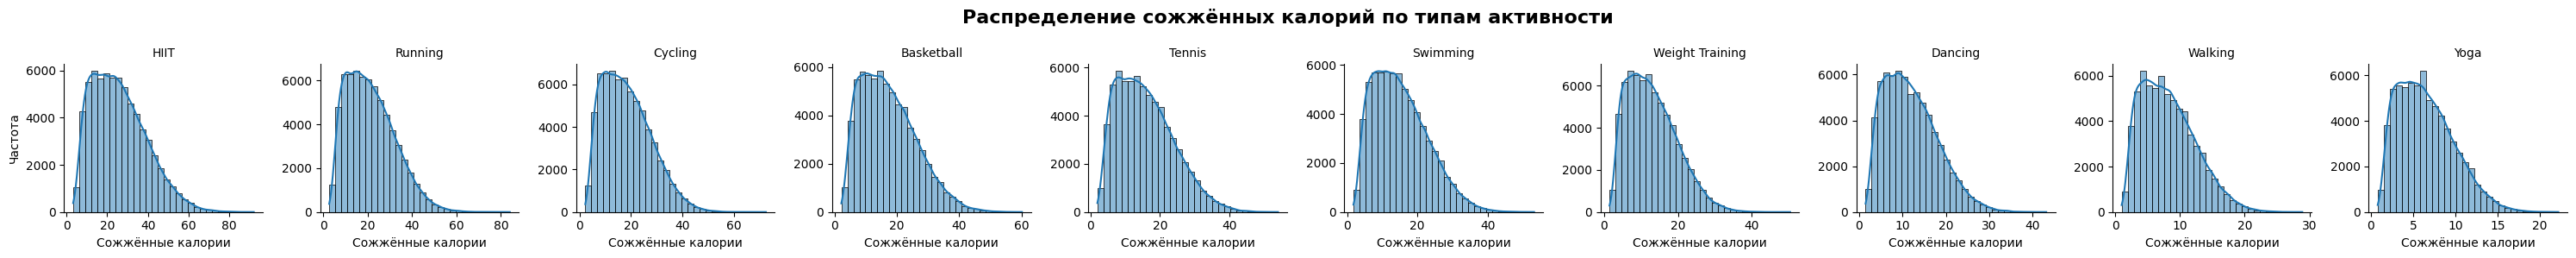

In [20]:
# Сортируем активности по средней калорийности
activity_order = df.groupby('activity_type')['calories_burned'].mean().sort_values(ascending=False).index.tolist()

# Создаём сетку гистограмм
g = sns.FacetGrid(df, col='activity_type', col_order=activity_order,
                  height=3, aspect=1, sharex=False, sharey=False)
g.map(sns.histplot, 'calories_burned', bins=30, kde=True)
g.set_axis_labels('Сожжённые калории', 'Частота')
g.set_titles('{col_name}')
g.figure.suptitle('Распределение сожжённых калорий по типам активности', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### Какую информацию подчёркивает Гистограмма?
* Форма распределения: распределение для Running и велоспорта Cycling выглядит более «пиковым», что может указывать на концентрацию значений в определённом диапазоне.
* Частота встречаемости: для Yoga большинство значений сосредоточено в нижнем диапазоне (около 6–7 ккал).
* Можно оценить, является ли распределение симметричным или смещённым, а также найти наиболее часто встречающееся значение (моду).

### Какие гипотезы можно заметить?
* как часто встречаются определённые уровни калорий для каждой активности;
* есть ли «пики» в распределении;
* насколько узким или широким является распределение (узкий пик говорит о стабильности, широкое распределение — о высокой вариабельности).

In [ ]:
# # Создаём violin plot
# plt.figure(figsize=(12, 6))
# sns.violinplot(x='activity_type', y='calories_burned', data=df, palette='Set3', cut=0)

# plt.title('Распределение возраста по типам физической активности (Violin plot)',
#           fontsize=16, fontweight='bold')
# plt.xlabel('Тип активности', fontsize=12)
# plt.ylabel('Возраст (лет)', fontsize=12)
# plt.xticks(rotation=45, ha='right')
# plt.grid(True, alpha=0.3, axis='y')

# plt.tight_layout()
# plt.show()